In [1]:
import os
print(os.listdir('/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset'))

['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

print("Shape:", df.shape)
df.head()

Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 1. Statistical Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:

df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [5]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [6]:
# Class distribution of target variable
print("Target variable distribution:")
print(df['Diabetes_binary'].value_counts())
print("\nPercentage:")
print(df['Diabetes_binary'].value_counts(normalize=True) * 100)

Target variable distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Percentage:
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


## 2. Visual Analysis

/tmp/ipykernel_17/3563610457.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_binary', data=df, palette='Set2')


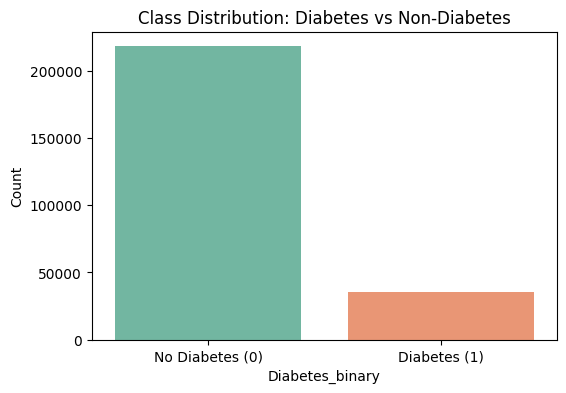

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes_binary', data=df, palette='Set2')
plt.title('Class Distribution: Diabetes vs Non-Diabetes')
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.ylabel('Count')
plt.show()

```
The target variable is highly imbalanced — 86% non-diabetic and 14% diabetic. 
This imbalance will need to be addressed during preprocessing.

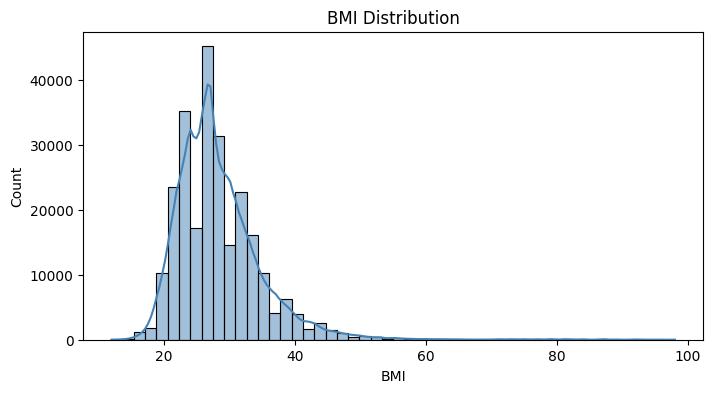

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(df['BMI'], bins=50, kde=True, color='steelblue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

BMI is right-skewed with most values between 20-40. 
Maximum value of 98 suggests presence of outliers

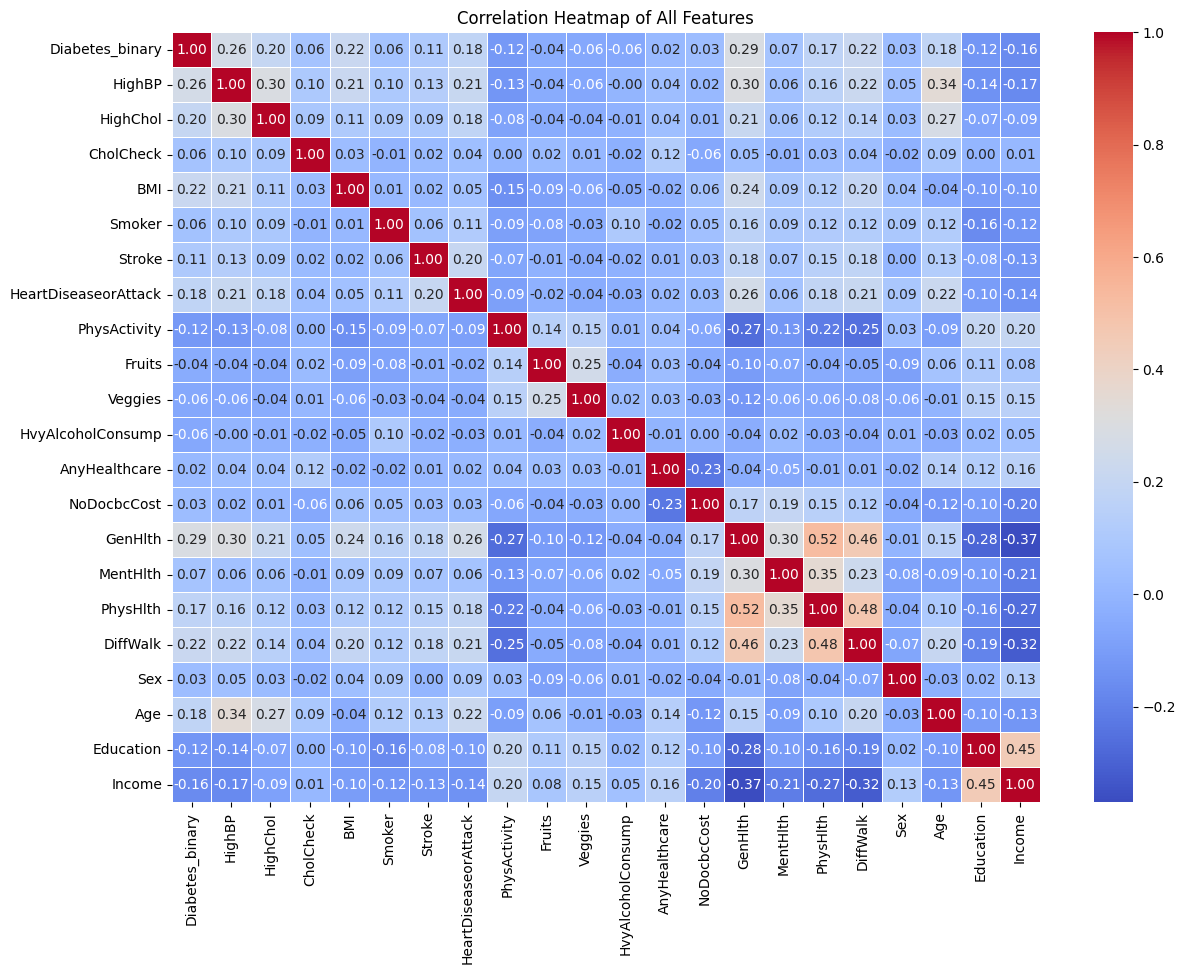

In [9]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.show()

GenHlth, HighBP, BMI, DiffWalk, and HighChol show 
the strongest positive correlation with diabetes outcome.

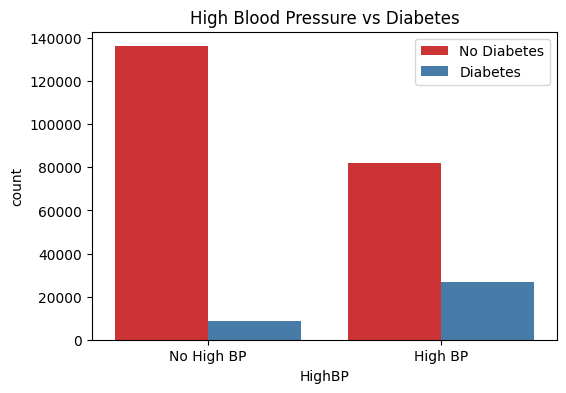

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='HighBP', hue='Diabetes_binary', data=df, palette='Set1')
plt.title('High Blood Pressure vs Diabetes')
plt.xticks([0,1], ['No High BP', 'High BP'])
plt.legend(['No Diabetes', 'Diabetes'])
plt.show()

People with High Blood Pressure show a much higher 
rate of diabetes compared to those without it.

/tmp/ipykernel_17/3959336178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_binary', y='BMI', data=df, palette='Set2')


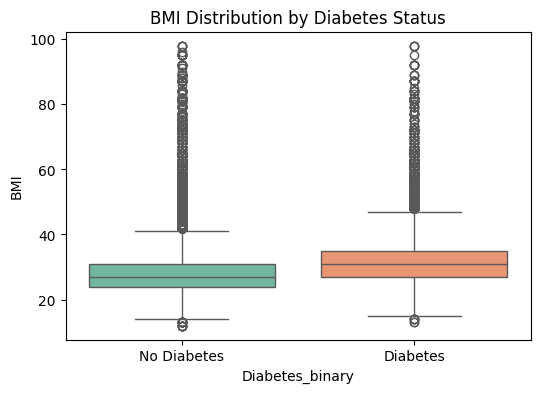

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Diabetes_binary', y='BMI', data=df, palette='Set2')
plt.title('BMI Distribution by Diabetes Status')
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.show()

Diabetic patients have a noticeably higher median BMI (32) 
compared to non-diabetic patients (27). Outliers are visible above BMI 60.

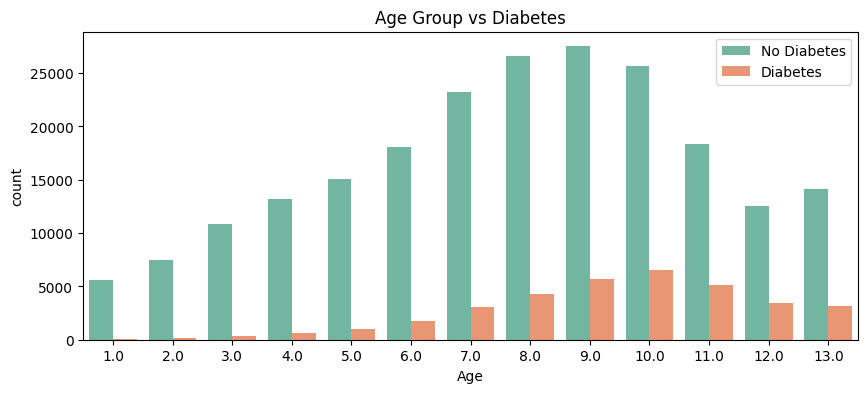

In [12]:
plt.figure(figsize=(10,4))
sns.countplot(x='Age', hue='Diabetes_binary', data=df, palette='Set2')
plt.title('Age Group vs Diabetes')
plt.legend(['No Diabetes', 'Diabetes'])
plt.show()

Diabetes cases increase significantly with age, 
with peak occurrence in age groups 8-11 (middle-aged to elderly).
Note: Age is encoded as categories (1=18-24, 13=80+).

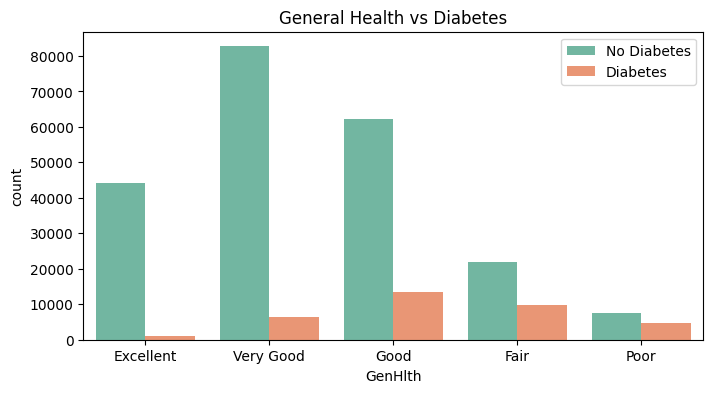

In [13]:
plt.figure(figsize=(8,4))
sns.countplot(x='GenHlth', hue='Diabetes_binary', data=df, palette='Set2')
plt.title('General Health vs Diabetes')
plt.xticks([0,1,2,3,4], ['Excellent','Very Good','Good','Fair','Poor'])
plt.legend(['No Diabetes', 'Diabetes'])
plt.show()


As general health worsens (from Excellent to Poor), 
the proportion of diabetic patients increases significantly.

## 3. Preprocessing

In [14]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())
print("New shape:", df.shape)


Duplicates before: 24206
Duplicates after: 0
New shape: (229474, 22)


Duplicate rows were removed as they don't add new information 
and can bias the model towards repeated patterns.

In [15]:
print("BMI Stats:")
print("Min:", df['BMI'].min())
print("Max:", df['BMI'].max())
print("Mean:", df['BMI'].mean().round(2))

# How many rows have BMI > 60?
print("\nRows with BMI > 60:", (df['BMI'] > 60).sum())




BMI Stats:
Min: 12.0
Max: 98.0
Mean: 28.69

Rows with BMI > 60: 805


Checking BMI for extreme outliers. BMI above 60 is medically 
very rare and may represent data entry errors.

In [16]:
df = df[df['BMI'] <= 60]
print("Shape after removing BMI outliers:", df.shape)
print("New BMI Max:", df['BMI'].max())


Shape after removing BMI outliers: (228669, 22)
New BMI Max: 60.0


Rows with BMI greater than 60 were removed as they represent 
less than 0.4% of data and are considered extreme outliers. 
A BMI above 60 is extremely rare medically and likely 
represents data entry errors.

In [17]:
print("Class distribution after cleaning:")
print(df['Diabetes_binary'].value_counts())
print("\nPercentage:")
print(df['Diabetes_binary'].value_counts(normalize=True).round(4) * 100)



Class distribution after cleaning:
Diabetes_binary
0.0    193743
1.0     34926
Name: count, dtype: int64

Percentage:
Diabetes_binary
0.0    84.73
1.0    15.27
Name: proportion, dtype: float64


Class imbalance still exists after cleaning. This will be 
addressed by using appropriate evaluation metrics (F1-score) 
and class_weight parameter during model training.

In [18]:
print("CholCheck value counts:")
print(df['CholCheck'].value_counts())



CholCheck value counts:
CholCheck
1.0    219396
0.0      9273
Name: count, dtype: int64


Checking CholCheck — if almost everyone has the same 
value, it won't help the model learn anything useful.

In [19]:
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (228669, 21)
Target shape: (228669,)



Separating features (X) and target variable (y) 
before applying feature scaling. We only scale 
the features, not the target column.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling done!")
print(X_scaled.describe().round(2))

Scaling done!
          HighBP   HighChol  CholCheck        BMI     Smoker     Stroke  \
count  228669.00  228669.00  228669.00  228669.00  228669.00  228669.00   
mean        0.00      -0.00      -0.00      -0.00       0.00      -0.00   
std         1.00       1.00       1.00       1.00       1.00       1.00   
min        -0.91      -0.89      -4.86      -2.68      -0.93      -0.22   
25%        -0.91      -0.89       0.21      -0.73      -0.93      -0.22   
50%        -0.91      -0.89       0.21      -0.25      -0.93      -0.22   
75%         1.10       1.12       0.21       0.56       1.07      -0.22   
max         1.10       1.12       0.21       5.10       1.07       4.62   

       HeartDiseaseorAttack  PhysActivity     Fruits    Veggies  ...  \
count             228669.00     228669.00  228669.00  228669.00  ...   
mean                  -0.00         -0.00       0.00       0.00  ...   
std                    1.00          1.00       1.00       1.00  ...   
min                   

StandardScaler was applied to normalize all features. 
This transforms each feature to have mean=0 and 
standard deviation=1, ensuring no single feature 
dominates due to its larger range. This is especially 
important for Logistic Regression and SVM models.

In [21]:
df_preprocessed = X_scaled.copy()
df_preprocessed['Diabetes_binary'] = y.values

# Save to CSV
df_preprocessed.to_csv('/kaggle/working/diabetes_preprocessed.csv', index=False)

print("File saved successfully!")
print("Final shape:", df_preprocessed.shape)

File saved successfully!
Final shape: (228669, 22)


Preprocessed dataset saved as CSV for use in next phases. 
In future phases, this cleaned and scaled file will be 
loaded directly instead of repeating the entire 
preprocessing pipeline, saving computation time.